<a href="https://colab.research.google.com/github/h-merritt/complexity72h/blob/main/c27_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

combined PCA



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

try:
    df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/hcp_social_mentahealth_data.csv')
    #change with location of your file location
    print("File loaded.")
except FileNotFoundError:
    print("Error 404: File not found.")
    df = None

#checking the file is, indeed, The File
if df is not None:
    print("\First 5 rows:")
    display(df.head())


<>:12: SyntaxWarning: invalid escape sequence '\F'
<>:12: SyntaxWarning: invalid escape sequence '\F'
/tmp/ipykernel_15320/3948658524.py:12: SyntaxWarning: invalid escape sequence '\F'
  print("\First 5 rows:")


File loaded.
\First 5 rows:


,Unnamed: 0,Subject,Gender,Age_Range,Life_Satisfaction,Purpose_In_Life,Positive_Affect,Friendship,Loneliness,Perceived_Hostility,...,ASR_Total_Problems,DSM_Depression,DSM_Anxiety,DSM_Somatic_Problems,DSM_Avoidant,DSM_ADHD,DSM_Inattention,DSM_Hyperactivity,DSM_Antisocial,LifeSatisf_Unadj.1
0,1,100004,M,22-25,-1.222763,-1.331336,-1.749523,-2.479994,2.478326,1.290594,...,0.374231,0.786522,-0.348821,-0.736914,1.420130,-0.183650,0.333889,-0.734062,1.780683,-1.222763
1,2,100206,M,26-30,-0.951417,-0.190695,-0.200365,-0.494016,1.432068,1.727998,...,2.165624,1.929686,1.131737,2.536263,1.849864,1.626088,1.182244,1.716904,0.853045,-0.951417
2,3,100307,F,26-30,-0.690925,-1.066339,-0.479722,1.294462,0.283460,0.450319,...,-0.849159,-0.928225,-0.348821,-0.736914,-0.728539,-0.442184,-0.938643,0.246324,-0.383806,-0.690925
3,4,100408,M,31-35,0.361897,0.028216,-0.200365,0.295987,0.078757,0.392765,...,-0.718082,-0.642434,-0.348821,-0.736914,-1.158272,-0.700718,-0.514465,-0.734062,-0.074593,0.361897
4,5,100610,M,26-30,0.622389,-0.559387,0.650402,-0.581794,0.260715,-1.184190,...,-0.499619,-0.642434,-1.459239,-0.736914,2.279598,-0.959252,-0.514465,-1.224256,-0.693018,0.622389


In [4]:
inner_variables = ['Positive_Affect', 'Self_Efficacy', 'Agreeableness', 'Openness','Conscientiousness', 'Neuroticism', 'Extraversion']
outer_variables = ['Friendship', 'Loneliness', 'Perceived_Hostility', 'Perceived_Rejection', 'Emotional_Support', 'Instrumental_Support', 'Perceived_Stress']

df_inner = df[inner_variables].copy()
df_outer = df[outer_variables].copy()



In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

def perform_pca(data_frame, title_prefix, is_z_score=True):


    print(f"\nRealizando PCA para variables {title_prefix}...")

    # 1. imputación con la media
    imputer = SimpleImputer(strategy='mean')
    data_imputed = imputer.fit_transform(data_frame)
    df_imputed = pd.DataFrame(data_imputed, columns=data_frame.columns, index=data_frame.index)

    # since we are already working with z score
    df_scaled = df_imputed # Si ya son z-scores, no es necesario escalar nuevamente

    # 3.  PCA
    pca = PCA(n_components=None) # n_components=None para mantener todos los componentes posibles
    principal_components = pca.fit_transform(df_scaled)

    # data feame with principal components
    pca_columns = [f'PC{i+1}' for i in range(principal_components.shape[1])]
    df_pca = pd.DataFrame(data=principal_components, columns=pca_columns, index=df_scaled.index)
    print(f"Análisis PCA para {title_prefix} completado.")

    # 4.  PCA results


    explained_variance_ratio = pca.explained_variance_ratio_
    for i, ratio in enumerate(explained_variance_ratio):
        print(f"PC{i+1}: {ratio:.2%}")

    cumulative_variance = explained_variance_ratio.cumsum()
    for i, cum_ratio in enumerate(cumulative_variance):
        print(f"PC{i+1}: {cum_ratio:.2%}")

    # plotting explained variance
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance, marker='o', linestyle='--')
    plt.title(f'Accumulated variance explained by ({title_prefix})')
    plt.xlabel('Number PCs')
    plt.ylabel('Accumulated explained variance')
    plt.grid(True)
    plt.show()

    # checking loads of the first two principal components
    if df_pca.shape[1] >= 2:
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.scatterplot(x='PC1', y='PC2', data=df_pca)
        plt.title(f'PCA - First two PCs ({title_prefix})')
        plt.xlabel(f'PC 1 ({explained_variance_ratio[0]:.2%})')
        plt.ylabel(f'PC 2 ({explained_variance_ratio[1]:.2%})')
        plt.grid(True)
        plt.show()

    print(f"\PCs loads{title_prefix}:")
    loadings = pd.DataFrame(pca.components_.T, columns=pca_columns, index=df_scaled.columns)
    display(loadings)
    return loadings



### PCA Combinado de Todas las Variables Relevantes

Ahora realizaremos un análisis PCA sobre un conjunto combinado de variables numéricas, sin distinción inicial entre 'inner' y 'outer'. El objetivo es observar cómo se agrupan las variables en los componentes principales y si esta agrupación es consistente con tu clasificación previa.

In [6]:
# Identificar todas las columnas numéricas (float64) para el PCA combinado
# Excluyendo 'Unnamed: 0', 'Subject' (IDs), 'Gender', 'Age_Range' (categóricas),
# y 'LifeSatisf_Unadj.1' (posiblemente redundante con Life_Satisfaction)

all_numeric_cols = inner_variables + outer_variables

# Excluir columnas que no son adecuadas para PCA o son redundantes
# Basado en el df.info() y el contexto de las variables:
columns_to_exclude = ['LifeSatisf_Unadj.1'] # Ya tenemos 'Life_Satisfaction', esta parece una versión unadjusted

combined_pca_variables = [col for col in all_numeric_cols if col not in columns_to_exclude]

# Asegurarse de que no estamos incluyendo IDs u otras columnas no deseadas que pudieran ser float64
# (Aunque df.info() ya nos muestra que las IDs no son float64, es una buena práctica)

print(f"selected variables with combined pca ({len(combined_pca_variables)}):\n{combined_pca_variables}")

df_combined_pca = df[combined_pca_variables].copy()


Variables seleccionadas para PCA combinado (14):
['Positive_Affect', 'Self_Efficacy', 'Agreeableness', 'Openness', 'Conscientiousness', 'Neuroticism', 'Extraversion', 'Friendship', 'Loneliness', 'Perceived_Hostility', 'Perceived_Rejection', 'Emotional_Support', 'Instrumental_Support', 'Perceived_Stress']

Primeras 5 filas del DataFrame combinado para PCA:


,Positive_Affect,Self_Efficacy,Agreeableness,Openness,Conscientiousness,Neuroticism,Extraversion,Friendship,Loneliness,Perceived_Hostility,Perceived_Rejection,Emotional_Support,Instrumental_Support,Perceived_Stress
0,-1.749523,-1.338285,-1.086714,-2.103481,-1.086169,0.974963,-0.945970,-2.479994,2.478326,1.290594,2.433991,-2.275289,-1.456288,0.754539
1,-0.200365,-0.813642,-0.743149,-0.828902,-1.423470,0.568738,0.227475,-0.494016,1.432068,1.727998,1.804832,-0.763447,-0.222482,1.016357
2,-0.479722,-1.588683,0.631111,-0.669579,0.094382,-0.243713,1.065649,1.294462,0.283460,0.450319,0.602689,-0.649541,0.471534,1.027266
3,-0.200365,0.664898,-0.056019,0.127033,-0.074268,-0.243713,0.395110,0.295987,0.078757,0.392765,0.153290,-0.121431,0.339341,-0.183644
4,0.650402,0.283339,-0.399584,0.764323,0.263032,-1.326980,-2.622319,-0.581794,0.260715,-1.184190,0.602689,0.572359,0.041905,-1.165463



Información general del DataFrame combinado para PCA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1206 entries, 0 to 1205
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Positive_Affect       1205 non-null   float64
 1   Self_Efficacy         1205 non-null   float64
 2   Agreeableness         1199 non-null   float64
 3   Openness              1199 non-null   float64
 4   Conscientiousness     1199 non-null   float64
 5   Neuroticism           1199 non-null   float64
 6   Extraversion          1199 non-null   float64
 7   Friendship            1205 non-null   float64
 8   Loneliness            1205 non-null   float64
 9   Perceived_Hostility   1205 non-null   float64
 10  Perceived_Rejection   1205 non-null   float64
 11  Emotional_Support     1204 non-null   float64
 12  Instrumental_Support  1204 non-null   float64
 13  Perceived_Stress      1205 non-null   float64
dtypes: float64(14)
me

None


Realizando PCA para variables Combinado...
Análisis PCA para Combinado completado.
PC1: 38.59%
PC2: 8.64%
PC3: 8.35%
PC4: 7.29%
PC5: 6.92%
PC6: 5.46%
PC7: 4.93%
PC8: 4.12%
PC9: 3.45%
PC10: 3.16%
PC11: 2.79%
PC12: 2.53%
PC13: 2.01%
PC14: 1.77%
PC1: 38.59%
PC2: 47.23%
PC3: 55.58%
PC4: 62.86%
PC5: 69.78%
PC6: 75.24%
PC7: 80.17%
PC8: 84.29%
PC9: 87.74%
PC10: 90.90%
PC11: 93.69%
PC12: 96.21%
PC13: 98.23%
PC14: 100.00%


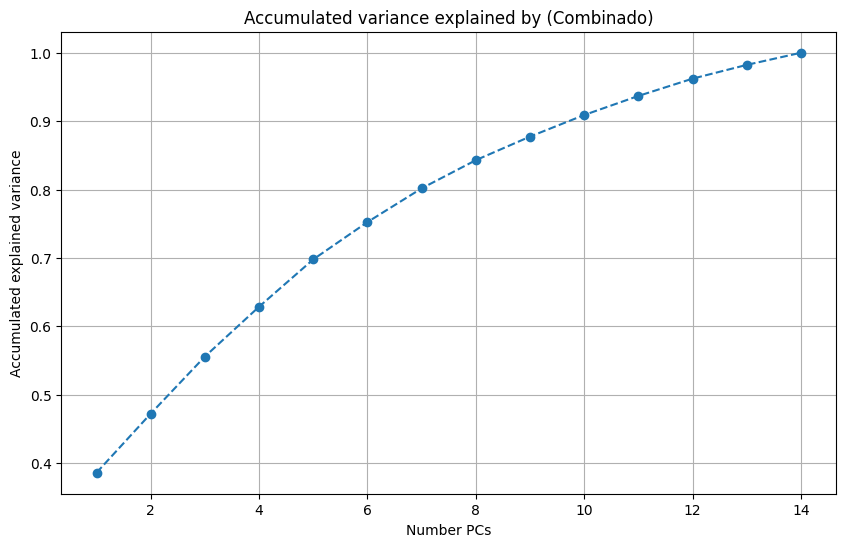

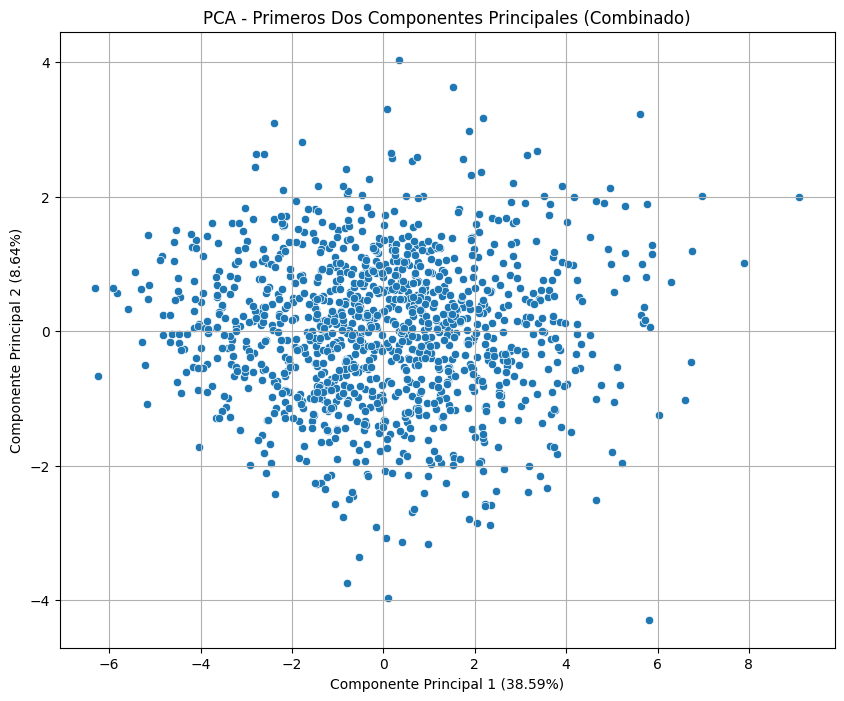


Cargas de los Componentes Principales (Loadings) para Combinado:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
Positive_Affect,-0.282364,-0.021814,0.166114,-0.186855,0.042722,0.070689,-0.466110,0.721902,-0.252278,-0.088311,-0.100253,0.085305,0.039679,-0.147371
Self_Efficacy,-0.257939,0.230475,0.388110,-0.121055,-0.311308,0.004359,0.325117,0.204979,0.361342,0.369921,-0.205017,-0.388323,0.093346,0.038289
Agreeableness,-0.184309,-0.143621,0.004817,0.556497,0.521585,0.394557,-0.119689,-0.000442,0.083414,0.338608,-0.202741,-0.143351,-0.055541,0.085371
Openness,0.000188,-0.382252,0.625450,0.398067,-0.327929,0.063623,0.135485,-0.093579,-0.313199,-0.242635,-0.000939,0.084502,0.005082,0.037510
Conscientiousness,-0.201922,0.491257,0.066406,0.046109,0.383198,-0.044644,0.563388,0.098413,-0.418911,-0.201812,-0.025566,0.106385,-0.083821,0.014864
Neuroticism,0.302282,-0.369883,-0.133001,-0.065739,0.072212,-0.236963,0.255752,0.415610,-0.032106,0.067886,-0.176610,-0.039217,-0.269877,0.582317
Extraversion,-0.242820,-0.126758,0.369409,-0.114103,0.440332,-0.325501,-0.087411,-0.076543,0.510565,-0.370375,0.205064,0.024520,-0.089719,0.116576
Friendship,-0.301205,-0.280887,0.060106,-0.208826,0.070118,-0.368728,0.058047,-0.240049,-0.168657,0.497710,-0.229557,0.384652,-0.204247,-0.250513
Loneliness,0.343584,-0.010762,0.120206,0.117614,0.036370,0.136285,0.214873,0.326130,0.234875,0.188093,0.426359,0.207162,-0.386350,-0.465418
Perceived_Hostility,0.250807,0.037026,0.333929,-0.482411,0.187264,0.307897,-0.166857,-0.264360,-0.266254,0.065334,-0.009493,-0.358083,-0.397946,0.045445



--- Visualización de las principales cargas por componente --- 


/tmp/ipykernel_15320/1294601990.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_loadings.values, y=top_loadings.index, palette='coolwarm') # Cambiado a coolwarm para mejor contraste de signo


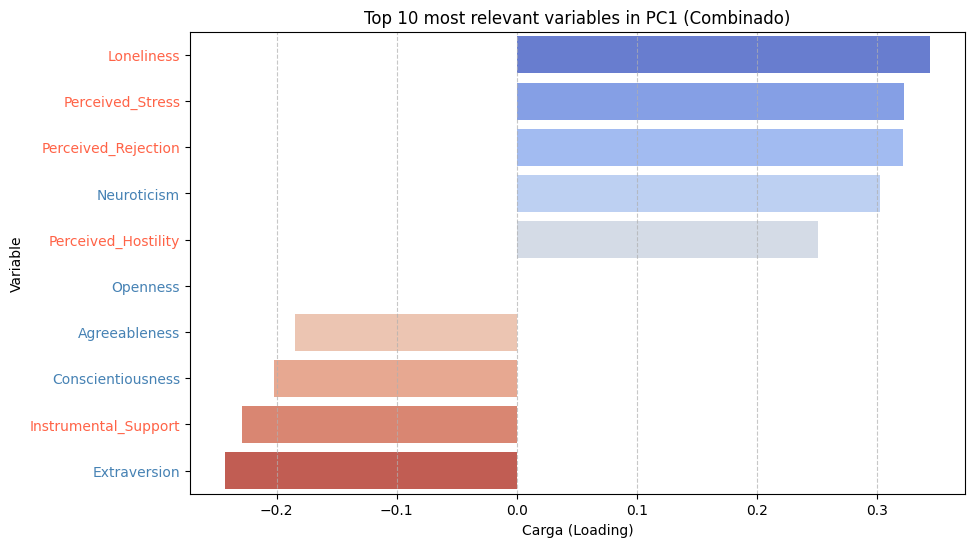

composition of top 10 variables in PC1 (Combinado):
  - Loneliness (Outer): 0.34
  - Perceived_Stress (Outer): 0.32
  - Perceived_Rejection (Outer): 0.32
  - Neuroticism (Inner): 0.30
  - Perceived_Hostility (Outer): 0.25
  - Openness (Inner): 0.00
  - Agreeableness (Inner): -0.18
  - Conscientiousness (Inner): -0.20
  - Instrumental_Support (Outer): -0.23
  - Extraversion (Inner): -0.24


/tmp/ipykernel_15320/1294601990.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_loadings.values, y=top_loadings.index, palette='coolwarm') # Cambiado a coolwarm para mejor contraste de signo


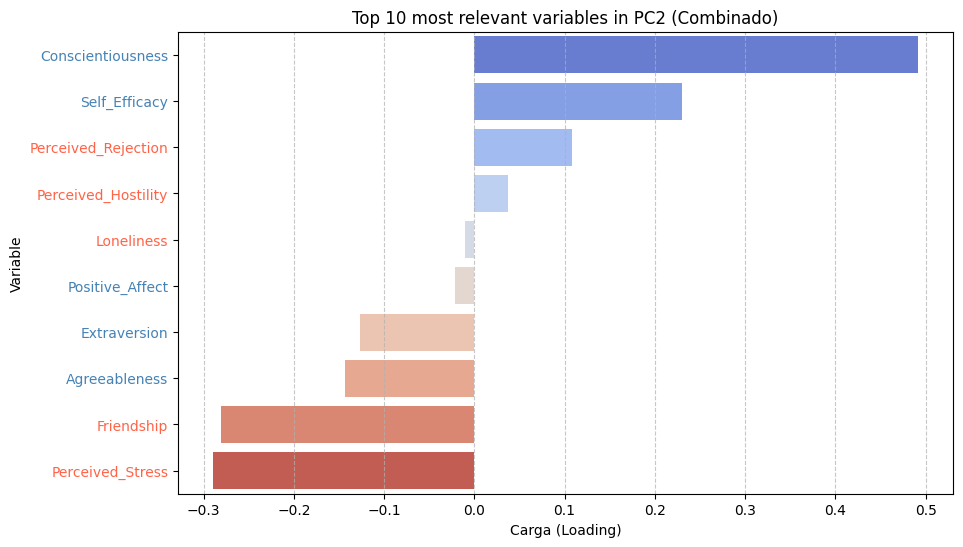

composition of top 10 variables in PC2 (Combinado):
  - Conscientiousness (Inner): 0.49
  - Self_Efficacy (Inner): 0.23
  - Perceived_Rejection (Outer): 0.11
  - Perceived_Hostility (Outer): 0.04
  - Loneliness (Outer): -0.01
  - Positive_Affect (Inner): -0.02
  - Extraversion (Inner): -0.13
  - Agreeableness (Inner): -0.14
  - Friendship (Outer): -0.28
  - Perceived_Stress (Outer): -0.29


In [11]:

loadings_combined = perform_pca(df_combined_pca, 'Combinado', is_z_score=True)


print("\n--- checking loadings for each component --- ")

def plot_top_loadings(loadings_df, pc_num, top_n=5, title_suffix=""):
    pc_col = f'PC{pc_num}'


    # ordering loads by value and sign
    top_loadings = loadings_df[pc_col].sort_values(ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=top_loadings.values, y=top_loadings.index, palette='coolwarm')
    plt.title(f'Top {top_n} most relevant variables in {pc_col} ({title_suffix})')
    plt.xlabel('Carga (Loading)')
    plt.ylabel('Variable')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    for label in ax.get_yticklabels():
        if label.get_text() in inner_variables:
            label.set_color('steelblue') # Colours for Inner
        elif label.get_text() in outer_variables:
            label.set_color('tomato') # Colours for Outer

    plt.show()


    print(f"composition of top {top_n} variables in {pc_col} ({title_suffix}):")
    for var_name, loading_val in top_loadings.items():
        if var_name in inner_variables:
            print(f"  - {var_name} (Inner): {loading_val:.2f}")
        elif var_name in outer_variables:
            print(f"  - {var_name} (Outer): {loading_val:.2f}")
        else:
            print(f"  - {var_name} (Otra): {loading_val:.2f}")

#plots
plot_top_loadings(loadings_combined, 1, top_n=10, title_suffix="Combinado")
plot_top_loadings(loadings_combined, 2, top_n=10, title_suffix="Combinado")


now for inner and outer separately

In [2]:

# pca for inner
loadings_inner = perform_pca(df_inner, 'Inner', is_z_score=True)

print("\n--- Main loads (Inner) ---")
plot_top_loadings(loadings_inner, 1, top_n=7, title_suffix="Inner") # Top 7 para todas las variables Inner
plot_top_loadings(loadings_inner, 2, top_n=7, title_suffix="Inner")

# pca for outer
loadings_outer = perform_pca(df_outer, 'Outer', is_z_score=True)

print("\n--- main loads (Outer) ---")
plot_top_loadings(loadings_outer, 1, top_n=7, title_suffix="Outer") # Top 7 para todas las variables Outer
plot_top_loadings(loadings_outer, 2, top_n=7, title_suffix="Outer")

NameError: name 'perform_pca' is not defined